<a href="https://colab.research.google.com/github/amyahespanol/Amyah-Espanol-Statistical-Theory-APM1111/blob/main/Stats_FA11_Espanol.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

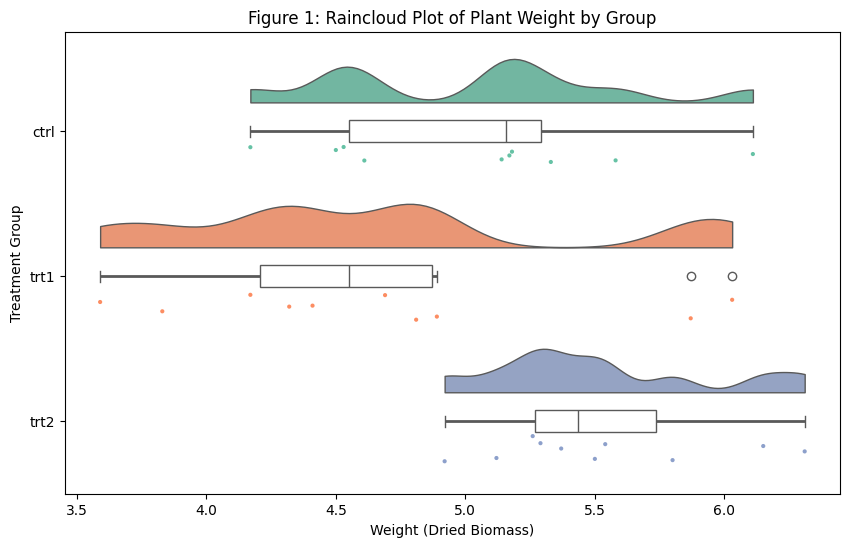

--- Table 1: Descriptive Statistics ---
  group  count   mean    std
0  ctrl     10  5.032  0.583
1  trt1     10  4.661  0.794
2  trt2     10  5.526  0.443


--- Table 2: Normality Test---
              W      pval  normal
group                            
ctrl   0.956681  0.747473    True
trt1   0.930411  0.451944    True
trt2   0.941005  0.564252    True


--- Table 3: Homogeneity of Variances ---
               W      pval  equal_var
levene  1.119186  0.341227       True


--- Table 4: One-Way ANOVA Results ---
   Source       SS  DF      MS       F   p_unc     np2
0   group   3.7663   2  1.8832  4.8461  0.0159  0.2641
1  Within  10.4921  27  0.3886     NaN     NaN     NaN


--- Table 5: Tukey Post-hoc Analysis ---
      A     B  mean_A  mean_B   diff      se       T  p_tukey  hedges
0  ctrl  trt1   5.032   4.661  0.371  0.2788  1.3308   0.3909  0.5102
1  ctrl  trt2   5.032   5.526 -0.494  0.2788 -1.7720   0.1980 -0.9140
2  trt1  trt2   4.661   5.526 -0.865  0.2788 -3.1028   0.0120 

In [11]:
!pip install pingouin statsmodels ptitprince -q

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pingouin as pg
import ptitprince as pt
from statsmodels.datasets import get_rdataset

#Load dataset
df = get_rdataset("PlantGrowth", "datasets").data

# Generate Raincloud Plot
plt.figure(figsize=(10, 6))

ax = pt.RainCloud(x='group', y='weight', hue='group', data=df,
                  palette='Set2', bw=0.2, width_viol=0.6,
                  orient='h', move=0.2)

plt.legend([], [], frameon=False)

plt.title('Figure 1: Raincloud Plot of Plant Weight by Group')
plt.xlabel('Weight (Dried Biomass)')
plt.ylabel('Treatment Group')
plt.show()

#Descriptive Statistics Table
desc = df.groupby('group')['weight'].agg(['count', 'mean', 'std']).reset_index()
print("--- Table 1: Descriptive Statistics ---")
print(desc.round(3))
print("\n")

#Assumption #5: Normality
print("--- Table 2: Normality Test---")
normality = pg.normality(data=df, dv='weight', group='group')
print(normality)
print("\n")

#Assumption #6: Levene's Test
print("--- Table 3: Homogeneity of Variances ---")
levene = pg.homoscedasticity(data=df, dv='weight', group='group')
print(levene)
print("\n")

#One-Way ANOVA
print("--- Table 4: One-Way ANOVA Results ---")
anova = pg.anova(data=df, dv='weight', between='group', detailed=True)
print(anova.round(4))
print("\n")

#Post-hoc Analysis
print("--- Table 5: Tukey Post-hoc Analysis ---")
posthoc = pg.pairwise_tukey(data=df, dv='weight', between='group')
print(posthoc.round(4))
